In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/dataset.csv")

# Show first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [3]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Duplicates: 0


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
# Drop rows with missing values
df = df.dropna()

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


In [9]:
df.dtypes

gender                         object
race/ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object

In [10]:
df['math_score'] = pd.to_numeric(df['math_score'])
df['reading_score'] = pd.to_numeric(df['reading_score'])
df['writing_score'] = pd.to_numeric(df['writing_score'])

In [11]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


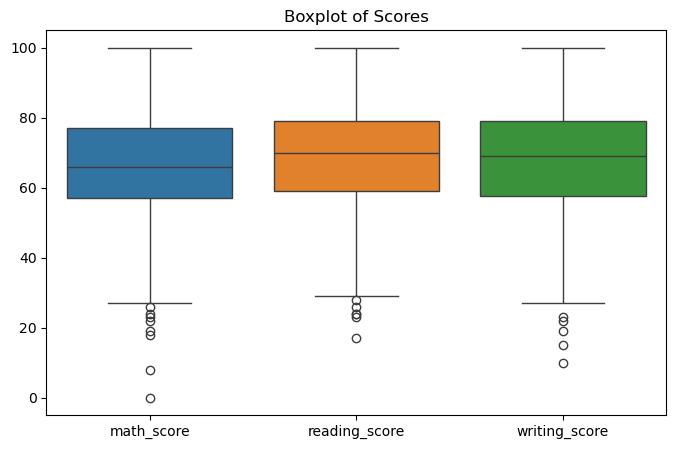

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df[['math_score','reading_score','writing_score']])
plt.title("Boxplot of Scores")
plt.savefig("../outputs/plots/boxplot.png")
plt.show()

In [13]:
for col in ['math_score','reading_score','writing_score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[col] >= Q1 - 1.5*IQR) & 
            (df[col] <= Q3 + 1.5*IQR)]

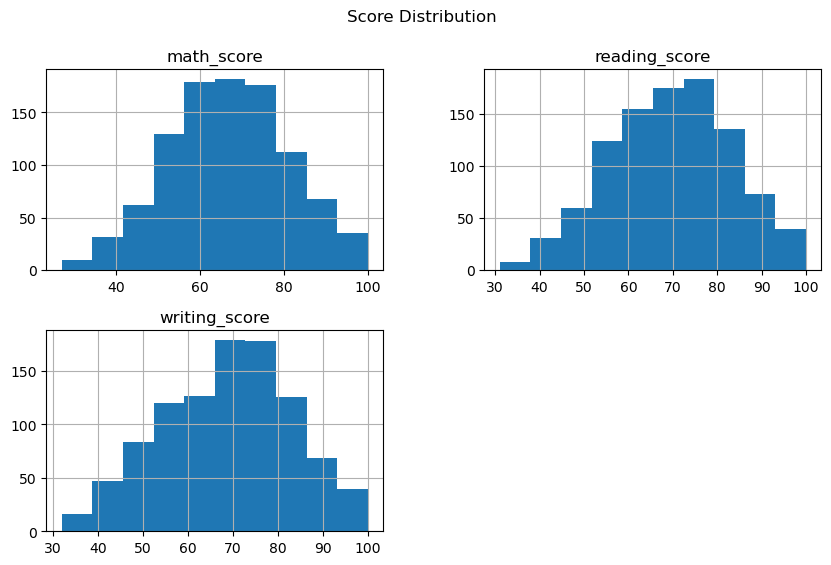

In [14]:
df[['math_score','reading_score','writing_score']].hist(figsize=(10,6))
plt.suptitle("Score Distribution")
plt.savefig("../outputs/plots/histogram.png")
plt.show()

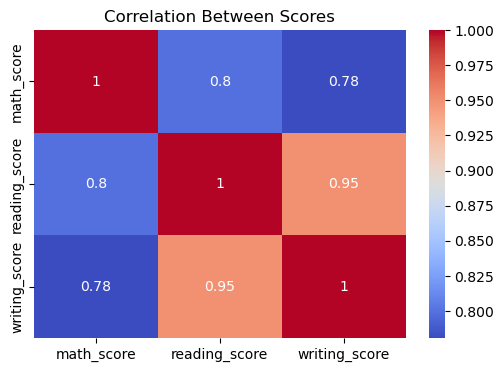

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math_score','reading_score','writing_score']].corr(),
            annot=True, cmap='coolwarm')

plt.title("Correlation Between Scores")
plt.savefig("../outputs/plots/heatmap.png")
plt.show()

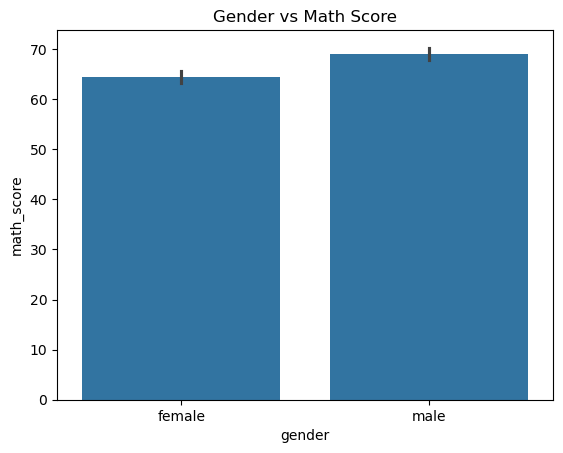

In [16]:
sns.barplot(x='gender', y='math_score', data=df)
plt.title("Gender vs Math Score")
plt.savefig("../outputs/plots/gender_math.png")
plt.show()

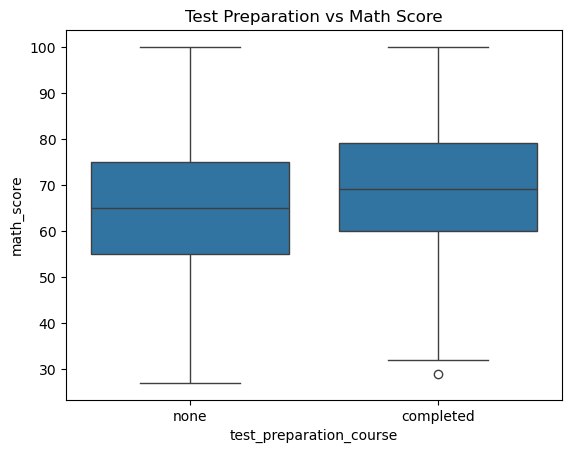

In [17]:
sns.boxplot(x='test_preparation_course', y='math_score', data=df)
plt.title("Test Preparation vs Math Score")
plt.savefig("../outputs/plots/test_prep.png")
plt.show()

In [18]:
df.to_csv("../outputs/cleaned_data.csv", index=False)